# Exercise 3: deep portfolio optimization

This notebook implements the feedback policy $\alpha_\theta(t,X_t,v_t^1,v_t^2)$ with the requested architecture $4\to16\to16\to2$ and ReLU activations. It uses the sample mean of negative terminal HARA utility as the loss.

Because the sheet omits several modelling assumptions, the implementation explicitly assumes:

* $W^1,W^2,B^1,B^2$ are jointly Brownian.
* The strategy is self-financing, with no consumption or external cash flows.
* Portfolio proportions are unconstrained, so the final network layer is linear.
* $\operatorname{Corr}(W^1,B^2)=\rho_2$ and $\operatorname{Corr}(W^2,B^1)=\rho_1$, following the requested reflected convention.
* Variances use projected full-truncation Euler; wealth uses exponential Euler, which preserves $X_t>0$.


## Controlled wealth and objective

Under self-financing,

$$
\frac{dX_t}{X_t}=\left[r+\alpha_t^1(\mu_1-r)+\alpha_t^2(\mu_2-r)\right]dt+\alpha_t^1\sqrt{v_t^1}\,dW_t^1+\alpha_t^2\sqrt{v_t^2}\,dW_t^2.
$$

For one simulated batch, the differentiable Monte Carlo loss is

$$
L(\theta)=-\frac{1}{N_{\mathrm{paths}}}\sum_{p=1}^{N_{\mathrm{paths}}}U\!\left(X_T^{(p),\theta}\right).
$$

At each time step, the current state produces the current control, and that control produces the next state:

$$
Z_n=(X_n,v_n^1,v_n^2),\qquad \alpha_n=\alpha_\theta(t_n,Z_n),\qquad Z_{n+1}=\Phi(Z_n,\alpha_n,\Delta W_n,\Delta B_n).
$$


In [48]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

# Reproducibility
SEED = 6
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
print(f"device: {DEVICE}")


device: cpu


In [49]:
# Model parameters
T = 1.0
X0 = 1.0
V0 = torch.tensor([0.10, 0.30], device=DEVICE, dtype=DTYPE)
R = 0.01
MU = torch.tensor([0.06, 0.10], device=DEVICE, dtype=DTYPE)
VBAR = torch.tensor([0.15, 0.25], device=DEVICE, dtype=DTYPE)
KAPPA = torch.tensor([0.10, 0.10], device=DEVICE, dtype=DTYPE)
XI = torch.tensor([0.15, 0.35], device=DEVICE, dtype=DTYPE)
GAMMA = 0.50

# Requested training parameters
N_STEPS = 200
N_PATHS = 10_000
N_EPOCHS = 200
DT = T / N_STEPS

RHO_12 = 0.30
RHO_V = 0.70
RHO_1 = 0.40
RHO_2 = 0.30

# Driver order: (W1, W2, B1, B2).
CORR = torch.tensor(
    [
        [1.0,    RHO_12, RHO_1, RHO_2],
        [RHO_12, 1.0,    RHO_1, RHO_2],
        [RHO_1,  RHO_1,  1.0,   RHO_V],
        [RHO_2,  RHO_2,  RHO_V, 1.0],
    ],
    device=DEVICE,
    dtype=DTYPE,
)

eigenvalues = torch.linalg.eigvalsh(CORR)
if eigenvalues.min().item() <= 0.0:
    raise ValueError(f"Correlation matrix is not positive definite: {eigenvalues}")
CHOL = torch.linalg.cholesky(CORR)
print("correlation eigenvalues:", eigenvalues.detach().cpu().numpy())


correlation eigenvalues: [0.2850445  0.70000017 0.7850612  2.229895  ]


The correlation matrix above is

$$
\begin{pmatrix}
1&0.3&0.4&0.3\\
0.3&1&0.4&0.3\\
0.4&0.4&1&0.7\\
0.3&0.3&0.7&1
\end{pmatrix}.
$$

Its positive eigenvalues verify that the jointly Gaussian increments exist under this convention.


In [50]:
def hara_utility(x: torch.Tensor, gamma: float = GAMMA) -> torch.Tensor:
    """HARA utility from the exercise."""
    if gamma == 0.0 or gamma == 1.0:
        raise ValueError("This parameterization requires gamma not in {0, 1}.")
    base = 1.0 + x / (1.0 - gamma)
    if torch.any(base <= 0.0):
        raise ValueError("HARA utility evaluated outside its domain.")
    return ((1.0 - gamma) / gamma) * base.pow(gamma)


class PolicyNet(nn.Module):
    """Unconstrained 4 -> 16 -> 16 -> 2 feedback policy."""

    def __init__(self) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2),
        )

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        return self.network(state)


policy = PolicyNet().to(device=DEVICE, dtype=DTYPE)
n_parameters = sum(parameter.numel() for parameter in policy.parameters())
assert n_parameters == 386
print(policy)
print(f"trainable parameters: {n_parameters}")


PolicyNet(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)
trainable parameters: 386


The network has $386$ trainable parameters, including biases, and $352$ weight multiplications per path and time step. For this fixed network, one training run costs

$$
\mathcal O\!\left(N_{\mathrm{epochs}}N_{\mathrm{paths}}N_{\mathrm{steps}}(C_{\mathrm{NN}}+C_{\mathrm{sim}})\right),
$$

where $C_{\mathrm{NN}}=352$ and dense generation of $d$ correlated drivers has $C_{\mathrm{sim}}=\mathcal O(d^2)$ after precomputing the Cholesky factor. Here $d=4$ is fixed.


In [51]:
def simulate(
    feedback_policy: nn.Module,
    n_paths: int = N_PATHS,
    return_history: bool = False,
):
    """Simulate the controlled state with differentiable torch operations."""
    x = torch.full((n_paths,), X0, device=DEVICE, dtype=DTYPE)
    v = V0.expand(n_paths, -1).clone()

    if return_history:
        x_history = [x]
        v_history = [v]
        alpha_history = []

    for step in range(N_STEPS):
        t = torch.full_like(x, step * DT)
        state = torch.column_stack((t, x, v))
        alpha = feedback_policy(state)

        # Joint Brownian increments in the order (W1, W2, B1, B2).
        independent_normals = torch.randn(
            (n_paths, 4), device=DEVICE, dtype=DTYPE
        )
        increments = math.sqrt(DT) * (independent_normals @ CHOL.T)
        d_w = increments[:, :2]
        d_b = increments[:, 2:]

        v_positive = v.clamp_min(0.0)
        sqrt_v = torch.sqrt(v_positive)

        # Exponential Euler for wealth, with coefficients frozen at t_n.
        risky_exposure = alpha * sqrt_v
        instantaneous_variance = (risky_exposure.square()).sum(dim=1)
        instantaneous_variance += (
            2.0 * RHO_12 * risky_exposure[:, 0] * risky_exposure[:, 1]
        )
        wealth_drift = R + (alpha * (MU - R)).sum(dim=1)
        log_increment = (
            (wealth_drift - 0.5 * instantaneous_variance) * DT
            + (risky_exposure * d_w).sum(dim=1)
        )
        x_next = x * torch.exp(log_increment)

        # Projected full-truncation Euler for the two CIR variances.
        v_next = (
            v
            + KAPPA * (VBAR - v_positive) * DT
            + XI * sqrt_v * d_b
        ).clamp_min(0.0)

        x, v = x_next, v_next
        if return_history:
            x_history.append(x)
            v_history.append(v)
            alpha_history.append(alpha)

    if return_history:
        history = {
            "x": torch.stack(x_history, dim=1),
            "v": torch.stack(v_history, dim=1),
            "alpha": torch.stack(alpha_history, dim=1),
        }
        return x, v, history
    return x, v


In [52]:
# Shape and finiteness smoke test before training.
with torch.no_grad():
    x_test, v_test, history_test = simulate(policy, n_paths=256, return_history=True)

assert x_test.shape == (256,)
assert v_test.shape == (256, 2)
assert history_test["x"].shape == (256, N_STEPS + 1)
assert history_test["v"].shape == (256, N_STEPS + 1, 2)
assert history_test["alpha"].shape == (256, N_STEPS, 2)
assert torch.isfinite(x_test).all() and (x_test > 0.0).all()
assert torch.isfinite(v_test).all() and (v_test >= 0.0).all()
print("simulation smoke test passed")


simulation smoke test passed


## Train by direct policy optimization

Each epoch uses a fresh batch of $10{,}000$ paths. Adam differentiates the negative sample-mean utility through all five simulated time steps.


In [53]:
optimizer = torch.optim.Adam(policy.parameters())  # PyTorch defaults, lr=1e-3
loss_history = []

policy.train()
for epoch in range(1, N_EPOCHS + 1):
    optimizer.zero_grad(set_to_none=True)
    terminal_wealth, _ = simulate(policy, n_paths=N_PATHS)
    loss = -hara_utility(terminal_wealth).mean()

    if not torch.isfinite(loss):
        raise FloatingPointError(f"Non-finite loss at epoch {epoch}.")

    loss.backward()
    optimizer.step()
    loss_history.append(loss.detach().item())

    if epoch == 1 or epoch % 25 == 0:
        print(f"epoch {epoch:4d} | loss {loss.item():.6f}")


epoch    1 | loss -1.740219
epoch   25 | loss -1.751898
epoch   50 | loss -1.760571
epoch   75 | loss -1.765822
epoch  100 | loss -1.764585
epoch  125 | loss -1.773824
epoch  150 | loss -1.769176
epoch  175 | loss -1.764182
epoch  200 | loss -1.771157


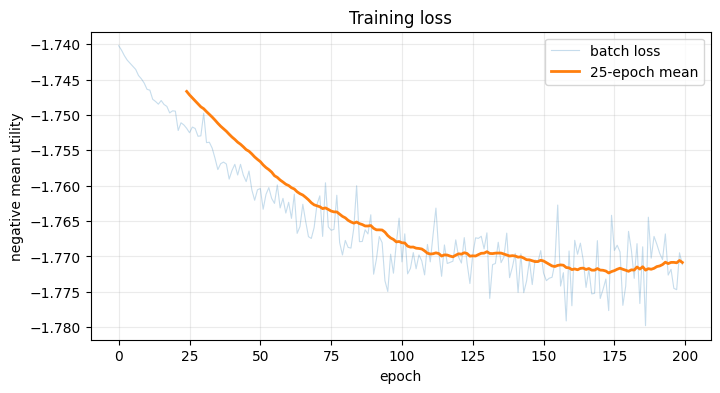

In [57]:
def moving_average(values, window=25):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return np.arange(len(values)), values
    smooth = np.convolve(values, np.ones(window) / window, mode="valid")
    return np.arange(window - 1, len(values)), smooth

smooth_epochs, smooth_loss = moving_average(loss_history, window=25)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, alpha=0.25, linewidth=0.8, label="batch loss")
ax.plot(smooth_epochs, smooth_loss, linewidth=2.0, label="25-epoch mean")
ax.set(xlabel="epoch", ylabel="negative mean utility", title="Training loss")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


In [58]:
# Independent Monte Carlo evaluation of the learned policy.
torch.manual_seed(SEED + 1)
policy.eval()
with torch.no_grad():
    terminal_wealth, terminal_variance = simulate(policy, n_paths=N_PATHS)
    terminal_utility = hara_utility(terminal_wealth)
    utility_estimate = terminal_utility.mean().item()
    utility_se = terminal_utility.std(unbiased=True).item() / math.sqrt(N_PATHS)

risk_free_terminal_wealth = X0 * math.exp(R * T)
risk_free_utility = hara_utility(
    torch.tensor(risk_free_terminal_wealth, device=DEVICE, dtype=DTYPE)
).item()

print(f"learned E[U(X_T)] : {utility_estimate:.6f} +/- {1.96 * utility_se:.6f} (95% MC CI)")
print(f"risk-free U(X_T)   : {risk_free_utility:.6f}")
print(f"mean terminal X    : {terminal_wealth.mean().item():.6f}")
print(f"std terminal X     : {terminal_wealth.std(unbiased=True).item():.6f}")


learned E[U(X_T)] : 1.772339 +/- 0.006222 (95% MC CI)
risk-free U(X_T)   : 1.737844
mean terminal X    : 1.120981
std terminal X     : 0.592864


## Question 6: learned strategy surfaces

The plots below evaluate both controls over $(v_1,v_2)$ for four fixed $(t,x)$ pairs. Regions far from states visited during training are extrapolations and should be interpreted cautiously.


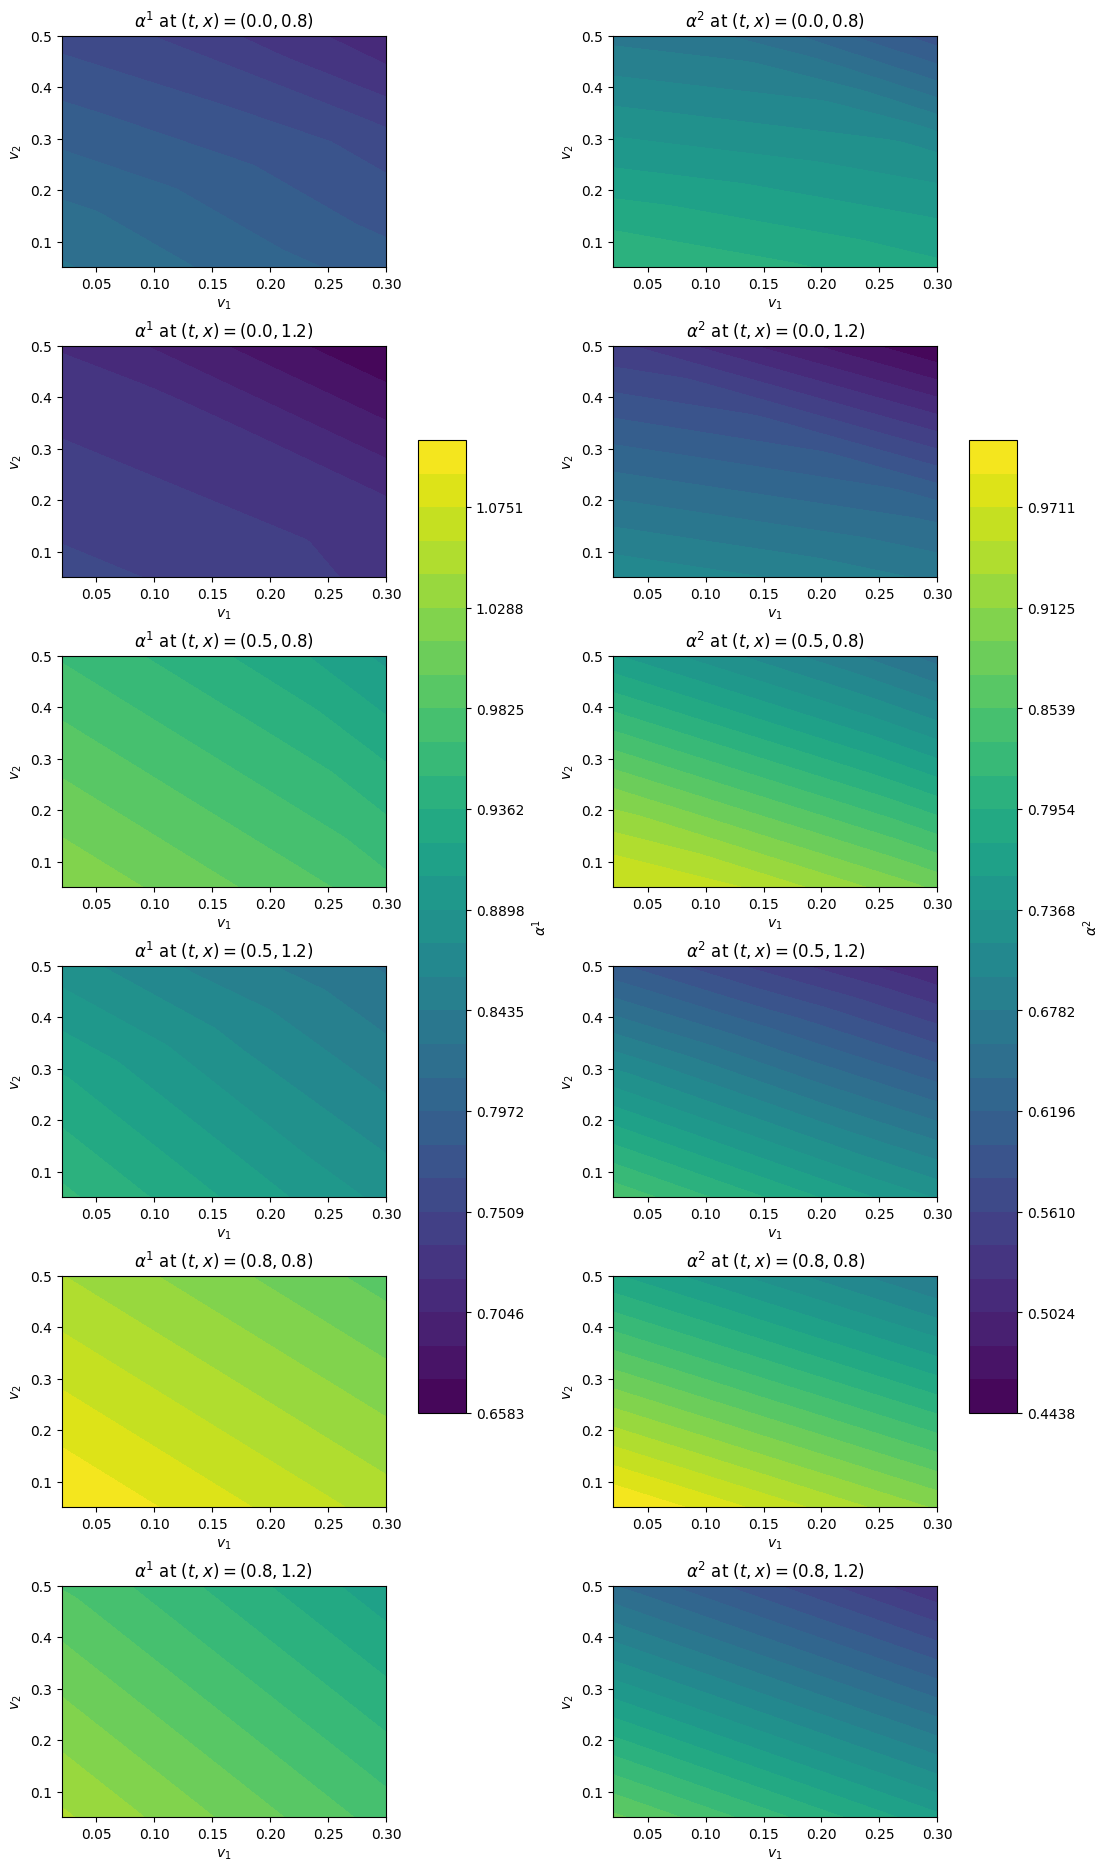

In [60]:
def policy_surfaces(
    feedback_policy: nn.Module,
    fixed_tx=(
        (0.0, 0.8),
        (0.0, 1.2),
        (0.5, 0.8),
        (0.5, 1.2),
        (0.8, 0.8),
        (0.8, 1.2),
    ),
    n_grid=60,
):
    v1_values = np.linspace(0.02, 0.30, n_grid)
    v2_values = np.linspace(0.05, 0.50, n_grid)
    v1_grid, v2_grid = np.meshgrid(v1_values, v2_values, indexing="xy")

    surfaces = []
    feedback_policy.eval()
    with torch.no_grad():
        for t_value, x_value in fixed_tx:
            inputs = np.column_stack(
                (
                    np.full(v1_grid.size, t_value),
                    np.full(v1_grid.size, x_value),
                    v1_grid.ravel(),
                    v2_grid.ravel(),
                )
            )
            inputs = torch.as_tensor(inputs, device=DEVICE, dtype=DTYPE)
            alpha = feedback_policy(inputs).cpu().numpy()
            surfaces.append(
                (alpha[:, 0].reshape(v1_grid.shape), alpha[:, 1].reshape(v1_grid.shape))
            )

    component_limits = []
    for component in range(2):
        component_values = np.concatenate(
            [surface[component].ravel() for surface in surfaces]
        )
        component_limits.append((component_values.min(), component_values.max()))

    fig, axes = plt.subplots(
        len(fixed_tx), 2, figsize=(11, 3.1 * len(fixed_tx)), constrained_layout=True
    )
    contours = [None, None]
    for row, ((t_value, x_value), surface) in enumerate(zip(fixed_tx, surfaces)):
        for component in range(2):
            lower, upper = component_limits[component]
            if math.isclose(lower, upper):
                upper = lower + 1e-8
            contours[component] = axes[row, component].contourf(
                v1_grid,
                v2_grid,
                surface[component],
                levels=np.linspace(lower, upper, 30),
                cmap="viridis",
            )
            axes[row, component].set(
                xlabel=r"$v_1$",
                ylabel=r"$v_2$",
                title=rf"$\alpha^{component + 1}$ at $(t,x)=({t_value:.1f},{x_value:.1f})$",
            )

    for component in range(2):
        fig.colorbar(
            contours[component],
            ax=axes[:, component],
            shrink=0.85,
            label=rf"$\alpha^{component + 1}$",
        )
    plt.show()


policy_surfaces(policy)
